# Huang et al. (2025) 再現（学習機構を選択可能）

このノートブックは論文 **"Transformers Learn to Implement Multi-step Gradient Descent with Chain of Thought"** の設定を使って、
学習機構を切り替えて比較できます。

- タスク: in-context weight prediction（線形回帰）
- モデル: one-layer linear self-attention（残差あり）
- 実験設定: `d=10, n=20, eta=0.4, batch_size=1000, adam_lr=1e-3, iterations=500`
- 学習モード `TRAINING_MODE`:
  - `"no_cot"`: 訓練時は CoT なし（`Z0` の1回読み出しで `w*` 回帰）
  - `"cot_split"`: k-step CoT 訓練（`k_train` 固定）+ 評価時 `k_eval` 掃引
  - `"cot_tied"`: k-step CoT 訓練と評価を同じ `k` で実行（train/eval 非分離）
- 主設定では CoT 学習・推論の初期条件を `w0=0` に固定
- 学習・推論時の最後の estimate token 更新では、source として labeled example token のみを使う data-source mask を適用

In [174]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ===== 実験設定 =====
D = 10
N = 12
M = 400  # 有限データ学習で使う固定タスク数（USE_FIXED_TRAIN_SET=True のとき）
ETA_GD = 0.4
BATCH_SIZE = 1000
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.1 # パラメータ正則化係数（0.0 で無効）
ITERATIONS = 4000  # 固定 iteration
EVAL_K_LIST = [0, 2, 4, 6, 8, 10]
W0_INIT_MODE = "random"  # 主設定では zero に固定
W0_GD_ETA = 0.001      # 互換性のため残すが主設定では未使用

TRAINING_MODE = "no_cot"   # "no_cot" | "cot_split" | "cot_tied"
COT_TRAIN_K = 1             # TRAINING_MODE="cot_split" のときに使用
COT_TIED_K_LIST = EVAL_K_LIST  # TRAINING_MODE="cot_tied" のときに使用
HEATMAP_K = COT_TIED_K_LIST[-1]  # cot_tied 時に可視化する k

SEED = 420

# 実行時間が長い場合だけここを True に変更
QUICK_MODE = False
if QUICK_MODE:
    BATCH_SIZE = 256
    ITERATIONS = 200

# ===== 有限 M 学習データ設定 =====
USE_FIXED_TRAIN_SET = True
TRAIN_TASKS_M = M

DE = 2 * D + 2

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"device={device}, d={D}, n={N}, B={BATCH_SIZE}, iters={ITERATIONS}, "
    f"w0={W0_INIT_MODE}, mode={TRAINING_MODE}, l2={PARAM_L2_LAMBDA}, "
    f"fixed_M={USE_FIXED_TRAIN_SET}, M={TRAIN_TASKS_M if USE_FIXED_TRAIN_SET else 'inf'}"
)

device=cpu, d=10, n=12, B=1000, iters=4000, w0=random, mode=no_cot, l2=0.1, fixed_M=True, M=400


In [175]:
def sample_batch(batch_size, d=D, n=N, device=device):
    """
    X: [B, d, n], w_star: [B, d], y: [B, n]
    x_i, w* ~ N(0, I), y_i = <w*, x_i>
    """
    X = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, X)
    return X, y, w_star


def build_fixed_train_dataset(M=TRAIN_TASKS_M):
    """有限 M の固定学習データセットを作る。"""
    X, y, w_star = sample_batch(M)
    return {"X": X, "y": y, "w_star": w_star, "M": M}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    """固定学習データからランダムにミニバッチ抽出する。"""
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    X = train_data["X"][idx]
    y = train_data["y"][idx]
    w_star = train_data["w_star"][idx]
    return X, y, w_star


def get_train_batch(train_data=None, batch_size=BATCH_SIZE):
    """学習バッチ取得の統一インターフェイス（固定 M / 無限サンプル切替）。"""
    if train_data is None:
        return sample_batch(batch_size)
    return sample_train_minibatch(train_data, batch_size)


def sample_w0(X, y, d=D, n=N, device=device):
    """初期条件 w0 を設定値に応じて生成する。"""
    batch_size = X.shape[0]
    if W0_INIT_MODE == "zero":
        return torch.zeros(batch_size, d, device=device)
    if W0_INIT_MODE == "random":
        s = 1.0
        #s = torch.empty(batch_size, 1, device=device).uniform_(0.01, 1.0)
        return torch.randn(batch_size, d, device=device) * s
    if W0_INIT_MODE == "gd1":
        # 線形回帰損失で w=0 からの1-step GD: w1 = (eta/n) Xy
        return (W0_GD_ETA / n) * torch.einsum("bdn,bn->bd", X, y)
    raise ValueError(f"Unknown W0_INIT_MODE: {W0_INIT_MODE}")


def gt_weights(X, y, w_star, k, eta=ETA_GD):
    """
    w_0=0 から始める ground-truth GD の軌跡 [w_0, ..., w_k, w_{k+1}=w*] を返す
    """
    B, d, n = X.shape
    w_list = [torch.zeros(B, d, device=X.device)]
    for _ in range(k):
        w_prev = w_list[-1]
        resid = torch.einsum("bdn,bd->bn", X, w_prev) - y
        grad = torch.einsum("bdn,bn->bd", X, resid) / n
        w_next = w_prev - eta * grad
        w_list.append(w_next)
    w_list.append(w_star)
    return w_list


def build_Z(X, y, w_prefix):
    """
    Z_i を構築。
    w_prefix は [w_0, ..., w_i] のリスト。
    戻り値: Z [B, de, n+i+1]
    """
    B, d, n = X.shape
    i = len(w_prefix) - 1
    L = n + i + 1

    Z = torch.zeros(B, DE, L, device=X.device)
    Z[:, :d, :n] = X
    Z[:, d, :n] = y

    for t, w_t in enumerate(w_prefix):
        col = n + t
        Z[:, d + 1 : d + 1 + d, col] = w_t

    Z[:, -1, :] = 1.0
    return Z


def build_data_src_mask(T, n, device):
    """source として example token のみを使う mask を返す。"""
    mask = torch.zeros(T, device=device)
    mask[:n] = 1.0
    return mask


def f_lsa_last(Z, V, W, n=N, src_mask=None):
    """
    f_LSA(Z;V,W)[:, -1] = Z[:, -1] + V Z (Z^T W Z[:, -1]) / n
    Z: [B, de, T], V/W: [de, de]
    src_mask: [T] or [B, T], 1=use, 0=mask out
    return: [B, de]
    """
    z_last = Z[:, :, -1]                           # [B, de]
    Wz = torch.einsum("ij,bj->bi", W, z_last)      # [B, de]
    scores = torch.einsum("bdt,bd->bt", Z, Wz) / n # [B, T]

    if src_mask is not None:
        if src_mask.dim() == 1:
            src_mask = src_mask.unsqueeze(0)       # [1, T]
        scores = scores * src_mask                 # source token selection

    weighted = torch.einsum("bdt,bt->bd", Z, scores)  # [B, de]
    out_last = z_last + torch.einsum("ij,bj->bi", V, weighted)
    return out_last
    


def cot_loss(V, W, X, y, w_star, k):
    """
    Eq.(5) 相当: 1/2 * sum_{i=0..k} || f(Z_i)[:,-1] - (0,0,w_{i+1},1) ||^2
    学習時は CoT token を source に使わず、example token のみを source に使う。
    """
    w_list = gt_weights(X, y, w_star, k)
    total = 0.0
    n = X.shape[2]

    for i in range(k + 1):
        Z_i = build_Z(X, y, w_list[: i + 1])
        src_mask = build_data_src_mask(Z_i.shape[2], n=n, device=Z_i.device)
        pred = f_lsa_last(Z_i, V, W, n=n, src_mask=src_mask)

        target = torch.zeros_like(pred)
        target[:, D + 1 : D + 1 + D] = w_list[i + 1]
        target[:, -1] = 1.0

        total = total + 0.5 * ((pred - target) ** 2).sum(dim=1).mean()

    return total


def no_cot_train_loss(V, W, X, y, w_star):
    """
    no-CoT 訓練: w0=0 の Z0 から1回読み出し、真値 (0,0,w*,1) との誤差のみを最小化。
    source は example token のみに制限する。
    """
    B = X.shape[0]
    n = X.shape[2]
    # ここに注意
    # w0 = torch.zeros(B, D, device=X.device)
    w0 = sample_w0(X, y, D, N, X.device)
    Z0 = build_Z(X, y, [w0])
    src_mask = build_data_src_mask(Z0.shape[2], n=n, device=Z0.device)
    pred = f_lsa_last(Z0, V, W, n=n, src_mask=src_mask)

    target = torch.zeros_like(pred)
    target[:, D + 1 : D + 1 + D] = w_star
    target[:, -1] = 1.0

    loss = 0.5 * ((pred - target) ** 2).sum(dim=1).mean()
    return loss


def eval_loss(V, W, k_eval, batch_size=2048):
    """
    推論時に data-source mask を保ったまま k_eval 回だけ更新し、
    最終 estimate w_hat_k と w* の誤差を測る。
    """
    X, y, w_star = sample_batch(batch_size)

    with torch.no_grad():
        n = X.shape[2]
        w0 = torch.zeros(batch_size, D, device=device) 
        w_prefix = [w0]
        for _ in range(k_eval):
            Z = build_Z(X, y, w_prefix)
            src_mask = build_data_src_mask(Z.shape[2], n=n, device=Z.device)
            pred = f_lsa_last(Z, V, W, n=n, src_mask=src_mask)
            w_hat = pred[:, D + 1 : D + 1 + D]
            w_prefix.append(w_hat)

        w_hat_final = w_prefix[-1]
        loss = 0.5 * ((w_hat_final - w_star) ** 2).sum(dim=1).mean().item()

    return loss


def parameter_l2_penalty(V, W):
    """V, W に対する L2 正則化項（係数は外側で掛ける）。"""
    return V.pow(2).sum() + W.pow(2).sum()

In [176]:
def train_model_no_cot(train_data=None, iterations=ITERATIONS, log_every=1):
    """
    no-CoT 学習（訓練時は Z0 の1ステップ読み出しのみ）。
    返り値: (V, W, eval_curve)
    """
    V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)

    eval_curve = []
    for t in range(iterations):
        X, y, w_star = get_train_batch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(V, W, X, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            ev = eval_loss(V, W, k_eval=0)
            eval_curve.append(ev)

    return V.detach(), W.detach(), np.array(eval_curve)


def train_model_cot(k_train, train_data=None, iterations=ITERATIONS, log_every=1):
    """
    k-step CoT 学習。
    返り値: (V, W, eval_curve)
    """
    V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)

    eval_curve = []
    for t in range(iterations):
        X, y, w_star = get_train_batch(train_data, BATCH_SIZE)
        data_loss = cot_loss(V, W, X, y, w_star, k=k_train)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            ev = eval_loss(V, W, k_eval=k_train)
            eval_curve.append(ev)

    return V.detach(), W.detach(), np.array(eval_curve)

In [177]:
# 学習を実行（TRAINING_MODE で切替）
final_eval = {}
V_vis, W_vis = None, None
heatmap_label = ""

train_data = None
if USE_FIXED_TRAIN_SET:
    train_data = build_fixed_train_dataset(TRAIN_TASKS_M)
    print(f"fixed train dataset built: M={train_data['M']}")

if TRAINING_MODE == "no_cot":
    print("training with no-CoT objective ...")
    V_tr, W_tr, train_curve = train_model_no_cot(train_data=train_data, iterations=ITERATIONS)
    for k_eval in EVAL_K_LIST:
        final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval)
    result_label = f"no-CoT train, varying k_eval (w0={W0_INIT_MODE})"
    V_vis, W_vis = V_tr, W_tr
    heatmap_label = "no_cot"

elif TRAINING_MODE == "cot_split":
    print(f"training with CoT (fixed k_train={COT_TRAIN_K}) ...")
    V_tr, W_tr, train_curve = train_model_cot(k_train=COT_TRAIN_K, train_data=train_data, iterations=ITERATIONS)
    for k_eval in EVAL_K_LIST:
        final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval)
    result_label = f"CoT split: k_train={COT_TRAIN_K}, varying k_eval"
    V_vis, W_vis = V_tr, W_tr
    heatmap_label = f"cot_split(k_train={COT_TRAIN_K})"

elif TRAINING_MODE == "cot_tied":
    print(f"training with tied CoT over k={COT_TIED_K_LIST} ...")
    train_curve = None
    model_by_k = {}
    for k in COT_TIED_K_LIST:
        V_k, W_k, curve_k = train_model_cot(k_train=k, train_data=train_data, iterations=ITERATIONS)
        final_eval[k] = eval_loss(V_k, W_k, k_eval=k)
        model_by_k[k] = (V_k, W_k)
    result_label = "CoT tied: train/eval with same k"

    if HEATMAP_K not in model_by_k:
        raise ValueError(f"HEATMAP_K={HEATMAP_K} is not in COT_TIED_K_LIST={COT_TIED_K_LIST}")
    V_vis, W_vis = model_by_k[HEATMAP_K]
    heatmap_label = f"cot_tied(k={HEATMAP_K})"

else:
    raise ValueError(f"Unknown TRAINING_MODE: {TRAINING_MODE}")

print("done")
print(f"final eval loss ({result_label}):")
for k_eval in sorted(final_eval.keys()):
    print(f"k_eval={k_eval:>2}: {final_eval[k_eval]:.6f}")

fixed train dataset built: M=400
training with no-CoT objective ...
done
final eval loss (no-CoT train, varying k_eval (w0=random)):
k_eval= 0: 5.039932
k_eval= 2: 1.720435
k_eval= 4: 1.233419
k_eval= 6: 1.120354
k_eval= 8: 0.970392
k_eval=10: 0.893658


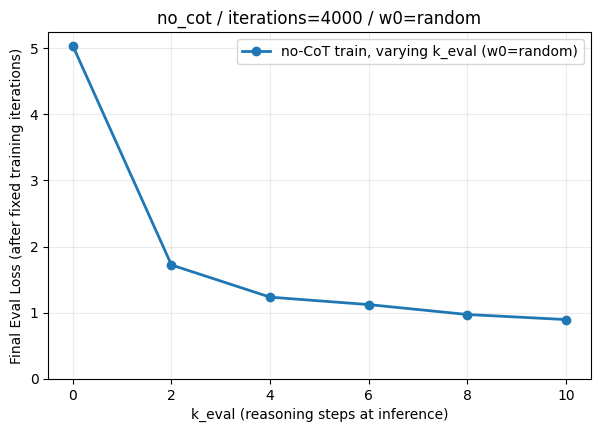

In [178]:
# iteration=ITERATIONS 固定で、横軸 k_eval の可視化
ks = np.array(sorted(final_eval.keys()))
vals = np.array([final_eval[k] for k in ks])

plt.figure(figsize=(7, 4.5))
plt.plot(ks, vals, marker="o", linewidth=2, label=result_label)

plt.xlabel("k_eval (reasoning steps at inference)")
plt.ylabel("Final Eval Loss (after fixed training iterations)")
plt.title(f"{TRAINING_MODE} / iterations={ITERATIONS} / w0={W0_INIT_MODE}")
plt.xticks(ks)
plt.ylim(bottom=0)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

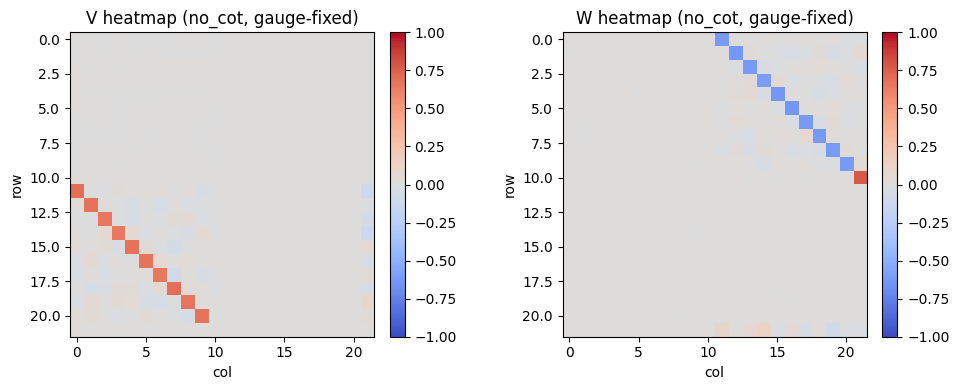

visualized model: no_cot
V shape=(22, 22), W shape=(22, 22)
gauge scale c=0.999141
product preservation ||V'W' - VW||_F=6.797e-08
fixed heatmap range=[-1.0, 1.0]


In [179]:
# 学習後パラメータの可視化（特定 k のモデル）
# (V, W) は (cV, W/c) のスケール同値性を持つため、可視化前に gauge-fix する。

HEATMAP_VMAX = 1.0  # 固定色スケール: [-HEATMAP_VMAX, HEATMAP_VMAX]

if V_vis is None or W_vis is None:
    raise ValueError("V_vis/W_vis is None. 先に学習セルを実行してください。")

V_np = V_vis.detach().cpu().numpy()
W_np = W_vis.detach().cpu().numpy()

# gauge-fix: ||V||_F と ||W||_F が一致するようにスケーリング
v_norm = np.linalg.norm(V_np, ord="fro")
w_norm = np.linalg.norm(W_np, ord="fro")
if v_norm > 0 and w_norm > 0:
    c = np.sqrt(w_norm / v_norm)
    V_plot = c * V_np
    W_plot = W_np / c
else:
    c = 1.0
    V_plot = V_np.copy()
    W_plot = W_np.copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(V_plot, cmap="coolwarm", vmin=-HEATMAP_VMAX, vmax=HEATMAP_VMAX)
axes[0].set_title(f"V heatmap ({heatmap_label}, gauge-fixed)")
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(W_plot, cmap="coolwarm", vmin=-HEATMAP_VMAX, vmax=HEATMAP_VMAX)
axes[1].set_title(f"W heatmap ({heatmap_label}, gauge-fixed)")
axes[1].set_xlabel("col")
axes[1].set_ylabel("row")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

prod_err = np.linalg.norm(V_plot @ W_plot - V_np @ W_np, ord="fro")
print(f"visualized model: {heatmap_label}")
print(f"V shape={V_np.shape}, W shape={W_np.shape}")
print(f"gauge scale c={c:.6f}")
print(f"product preservation ||V'W' - VW||_F={prod_err:.3e}")
print(f"fixed heatmap range=[{-HEATMAP_VMAX:.1f}, {HEATMAP_VMAX:.1f}]")

以下の実験条件だとうまくいきそう
-  attentionにmaskをつける
- 初期値は単純な正規分布からのrandomでよい
- 有限のMの設定

この場合だと、余計なパラメータが重みを持つことはなく、かつ、データが少ない場合の失敗の要因が、Iからの非対角成分が生まれてしまうことに起因することになる。